# Tutorial: Training a CNN for Waste Classification on Google Colab

This notebook trains a **Convolutional Neural Network (CNN) from scratch** for binary waste-image classification:

- **O**: Organic waste
- **R**: Recyclable waste

Dataset: **Waste Classification Data** by `techsash` on Kaggle.

## Learning objectives

1. Download a Kaggle image dataset directly into Google Colab.
2. Inspect its directory structure and class distribution.
3. Build TensorFlow training, validation, and test pipelines.
4. Apply image augmentation.
5. Design and train a CNN from scratch.
6. Evaluate accuracy, precision, recall, AUC, confusion matrix, and classification report.
7. Inspect misclassified images.
8. Compare CNN architecture settings and learning rates.

> **Recommended runtime:** Select **Runtime → Change runtime type → T4 GPU** in Google Colab.

## 1. Environment setup

The tutorial uses TensorFlow/Keras, KaggleHub, NumPy, Pandas, Matplotlib, and scikit-learn.

In [29]:
!nvidia-smi

Sat Jul 25 15:28:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             34W /   70W |    3741MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [30]:
!pip -q install -U kagglehub

In [31]:
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('Available GPUs:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Download the dataset from Kaggle

`kagglehub.dataset_download()` downloads the public dataset and returns its local path.

When authentication is requested, run `kagglehub.login()` and paste an API token generated in your Kaggle account settings.

In [34]:
!pip -q install -U kagglehub

from pathlib import Path
import kagglehub

DATASET_HANDLE = "techsash/waste-classification-data"
DOWNLOAD_DIR = "/content/"

dataset_path = Path(
    kagglehub.dataset_download(
        DATASET_HANDLE,
        output_dir=DOWNLOAD_DIR,
    )
)

print("Dataset downloaded to:")
print(dataset_path)

Using Colab cache for faster access to the 'waste-classification-data' dataset.
Dataset downloaded to:
/kaggle/input/waste-classification-data


## 3. Locate and inspect the image folders

The dataset normally contains separate `TRAIN` and `TEST` folders. The following code searches for them automatically and counts the actual image files instead of relying only on the dataset metadata.

In [35]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}

def count_images(folder: Path) -> int:
    return sum(
        1 for file_path in folder.rglob('*')
        if file_path.is_file() and file_path.suffix.lower() in IMAGE_EXTENSIONS
    )

def has_class_folders(folder: Path) -> bool:
    child_dirs = [path for path in folder.iterdir() if path.is_dir()]
    valid_children = [path for path in child_dirs if count_images(path) > 0]
    return len(valid_children) >= 2

all_dirs = [path for path in dataset_path.rglob('*') if path.is_dir()]
train_candidates = [
    path for path in all_dirs
    if path.name.upper() == 'TRAIN' and has_class_folders(path)
]
test_candidates = [
    path for path in all_dirs
    if path.name.upper() == 'TEST' and has_class_folders(path)
]

if not train_candidates or not test_candidates:
    raise FileNotFoundError(
        'Could not locate valid TRAIN and TEST directories. '
        'Inspect dataset_path and set TRAIN_DIR and TEST_DIR manually.'
    )

TRAIN_DIR = max(train_candidates, key=count_images)
TEST_DIR = max(test_candidates, key=count_images)

print('TRAIN_DIR:', TRAIN_DIR)
print('TEST_DIR :', TEST_DIR)
print('Training images:', count_images(TRAIN_DIR))
print('Test images    :', count_images(TEST_DIR))

TRAIN_DIR: /kaggle/input/waste-classification-data/DATASET/TRAIN
TEST_DIR : /kaggle/input/waste-classification-data/DATASET/TEST
Training images: 22564
Test images    : 2513


In [ ]:
def class_count_table(folder: Path, split_name: str) -> pd.DataFrame:
    rows = []
    for class_dir in sorted(path for path in folder.iterdir() if path.is_dir()):
        rows.append({
            'split': split_name,
            'folder_label': class_dir.name,
            'image_count': count_images(class_dir),
        })
    return pd.DataFrame(rows)

count_df = pd.concat([
    class_count_table(TRAIN_DIR, 'TRAIN'),
    class_count_table(TEST_DIR, 'TEST'),
], ignore_index=True)

count_df

,split,folder_label,image_count
0,TRAIN,O,12565
1,TRAIN,R,9999
2,TEST,O,1401
3,TEST,R,1112


In [ ]:
for split_dir in [TRAIN_DIR, TEST_DIR]:
    print(f'\n{split_dir.name}/')
    for class_dir in sorted(path for path in split_dir.iterdir() if path.is_dir()):
        print(f'  {class_dir.name}/  ({count_images(class_dir)} images)')


TRAIN/
  O/  (12565 images)
  R/  (9999 images)

TEST/
  O/  (1401 images)
  R/  (1112 images)


## 4. Visualize raw samples

Inspect examples before training to verify image readability, class labels, lighting, scale, viewpoint, and background diversity.

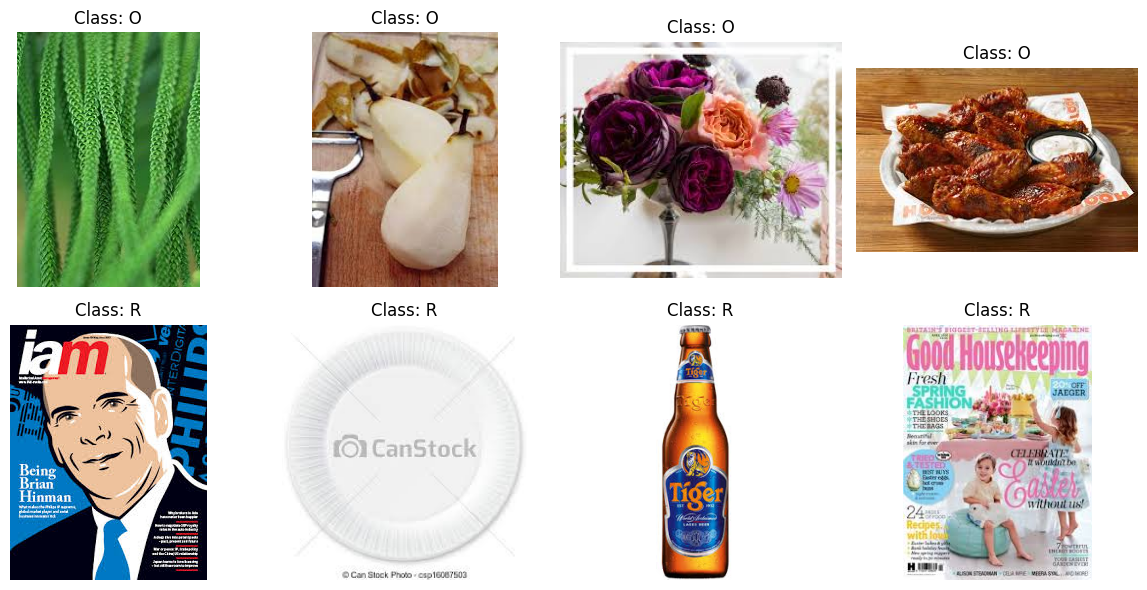

In [ ]:
from PIL import Image

class_dirs = sorted(path for path in TRAIN_DIR.iterdir() if path.is_dir())
plt.figure(figsize=(12, 6))

plot_index = 1
for class_dir in class_dirs:
    image_files = [
        path for path in class_dir.rglob('*')
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ]
    selected_files = random.sample(image_files, k=min(4, len(image_files)))

    for image_path in selected_files:
        with Image.open(image_path) as image:
            image = image.convert('RGB')
            ax = plt.subplot(len(class_dirs), 4, plot_index)
            ax.imshow(image)
            ax.set_title(f'Class: {class_dir.name}')
            ax.axis('off')
            plot_index += 1

plt.tight_layout()
plt.show()

## 5. Create TensorFlow datasets

- The original `TRAIN` folder is split into 80% training and 20% validation data.
- The original `TEST` folder is used only for final evaluation.
- `label_mode='binary'` is used because there are two classes.
- Test shuffling is disabled to keep labels aligned with predictions.

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.20

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
)

CLASS_NAMES = train_ds.class_names
assert CLASS_NAMES == test_ds.class_names, 'Train/test class orders are different.'

DISPLAY_NAME_MAP = {'O': 'Organic', 'R': 'Recyclable'}
DISPLAY_NAMES = [DISPLAY_NAME_MAP.get(name, name) for name in CLASS_NAMES]

print('Class order:', CLASS_NAMES)
print('Display names:', DISPLAY_NAMES)

for images, labels in train_ds.take(1):
    print('Image batch shape:', images.shape)
    print('Label batch shape:', labels.shape)
    print('Pixel range:', float(tf.reduce_min(images)), 'to', float(tf.reduce_max(images)))

Found 22564 files belonging to 2 classes.
Using 18052 files for training.
Found 22564 files belonging to 2 classes.
Using 4512 files for validation.
Found 2513 files belonging to 2 classes.
Class order: ['O', 'R']
Display names: ['Organic', 'Recyclable']
Image batch shape: (32, 128, 128, 3)
Label batch shape: (32, 1)
Pixel range: 0.0 to 255.0


## 6. Data augmentation and input performance

The augmentation pipeline applies horizontal flipping, small rotation, zoom, translation, and contrast changes. Augmentation is active only during training.

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(height_factor=0.08, width_factor=0.08),
    layers.RandomContrast(0.10),
], name='data_augmentation')

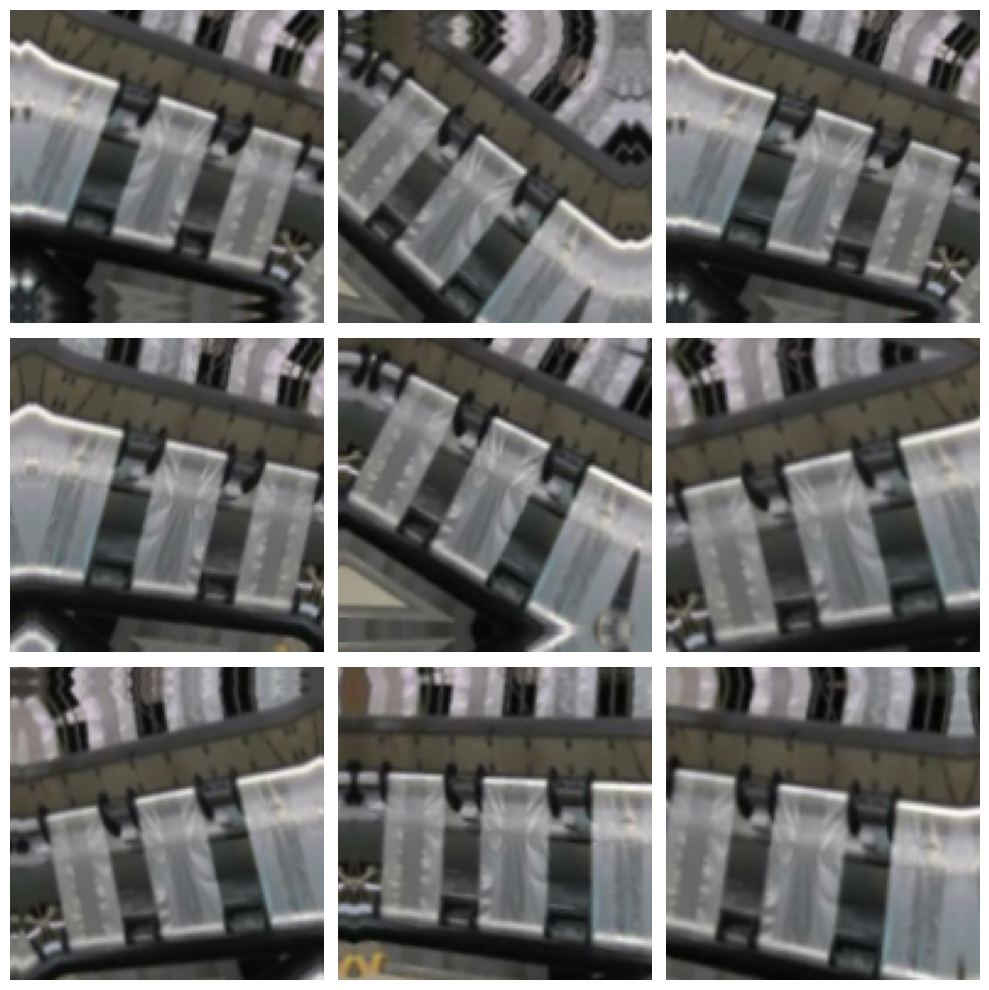

In [ ]:
sample_images, sample_labels = next(iter(train_ds))
sample_image = sample_images[0]

plt.figure(figsize=(10, 10))
for index in range(9):
    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, axis=0), training=True
    )
    ax = plt.subplot(3, 3, index + 1)
    ax.imshow(tf.cast(augmented_image[0], tf.uint8))
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

## 7. Build a CNN from scratch

The model contains data augmentation, pixel rescaling, convolutional blocks, batch normalization, max pooling, dropout, global average pooling, and a sigmoid classifier.

Each convolutional block adds three techniques that typically improve a from-scratch CNN:

- **Residual (skip) connections**: a 1x1 projection shortcut is added back to the block output before the final activation, which eases gradient flow and lets deeper stacks train reliably.
- **Squeeze-and-Excitation (SE) attention**: a lightweight channel-attention gate that reweights feature maps by their global importance instead of treating every channel equally.
- **L2 weight regularization** on convolutional and dense kernels, combined with **dropout that increases with depth** (later blocks, which have more parameters, are regularized more strongly).


In [ ]:
def se_block(x, reduction=8, name_prefix="se"):
    """Squeeze-and-Excitation channel attention gate."""
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D(name=f"{name_prefix}_pool")(x)
    se = layers.Dense(
        max(channels // reduction, 8), activation="relu",
        name=f"{name_prefix}_reduce"
    )(se)
    se = layers.Dense(channels, activation="sigmoid", name=f"{name_prefix}_expand")(se)
    se = layers.Reshape((1, 1, channels), name=f"{name_prefix}_reshape")(se)
    return layers.Multiply(name=f"{name_prefix}_scale")([x, se])


def conv_bn_relu(x, filters, name, l2_reg):
    x = layers.Conv2D(
        filters, 3, padding="same", use_bias=False,
        kernel_regularizer=keras.regularizers.l2(l2_reg),
        name=f"{name}_conv",
    )(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    x = layers.Activation("relu", name=f"{name}_relu")(x)
    return x


def build_cnn(
    image_size=IMG_SIZE,
    base_filters=32,
    num_blocks=3,
    dense_units=128,
    dropout_rate=0.35,
    l2_reg=1e-4,
):
    inputs = keras.Input(shape=(*image_size, 3), name='input_image')
    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255.0, name='rescaling')(x)

    filters = base_filters
    for block_index in range(num_blocks):
        block_name = f'block_{block_index + 1}'

        # 1x1 projection shortcut so the residual add matches the block's output channels
        shortcut = layers.Conv2D(
            filters, 1, padding='same', use_bias=False,
            kernel_regularizer=keras.regularizers.l2(l2_reg),
            name=f'{block_name}_shortcut_conv',
        )(x)
        shortcut = layers.BatchNormalization(name=f'{block_name}_shortcut_bn')(shortcut)

        x = conv_bn_relu(x, filters, f'{block_name}_1', l2_reg)
        x = conv_bn_relu(x, filters, f'{block_name}_2', l2_reg)
        x = se_block(x, name_prefix=f'{block_name}_se')

        x = layers.Add(name=f'{block_name}_residual_add')([x, shortcut])
        x = layers.Activation('relu', name=f'{block_name}_out_relu')(x)

        x = layers.MaxPooling2D(2, name=f'{block_name}_max_pool')(x)
        block_dropout = dropout_rate * (block_index + 1) / num_blocks / 2
        x = layers.Dropout(block_dropout, name=f'{block_name}_dropout')(x)
        filters *= 2

    x = layers.GlobalAveragePooling2D(name='global_average_pooling')(x)
    x = layers.Dense(
        dense_units, activation='relu',
        kernel_regularizer=keras.regularizers.l2(l2_reg),
        name='dense_features',
    )(x)
    x = layers.Dropout(dropout_rate, name='classifier_dropout')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='waste_probability')(x)

    return keras.Model(inputs, outputs, name='waste_cnn')

model = build_cnn()
model.summary()

## 8. Compile the model

Binary cross-entropy is used for training, Adam is used for optimization, and the initial learning rate is `0.001`.

In [ ]:
class F1Score(keras.metrics.Metric):
    """Binary F1 score, computed from Precision and Recall at a fixed threshold."""

    def __init__(self, name='f1', threshold=0.5, **kwargs):
        super().__init__(name=name, **kwargs)
        self.precision = keras.metrics.Precision(thresholds=threshold)
        self.recall = keras.metrics.Recall(thresholds=threshold)

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        precision = self.precision.result()
        recall = self.recall.result()
        return 2 * precision * recall / (precision + recall + keras.backend.epsilon())

    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()


LEARNING_RATE = 1e-3

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc'),
        F1Score(name='f1'),
    ],
)

## 9. Train the CNN

Callbacks stop training when validation loss no longer improves, reduce the learning rate on a plateau, and save the best model.

In [ ]:
EPOCHS = 25
BEST_MODEL_PATH = '/content/best_waste_cnn.keras'

# Class weights correct for imbalance between the two folders so the
# minority class isn't under-represented in the loss (and hurts F1 less).
train_counts = (
    count_df[count_df['split'] == 'TRAIN']
    .set_index('folder_label')['image_count']
)
total_images = train_counts.sum()
class_weight = {
    class_index: total_images / (len(CLASS_NAMES) * train_counts[class_name])
    for class_index, class_name in enumerate(CLASS_NAMES)
}
print('Class weights:', class_weight)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_f1', mode='max', patience=5,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_f1', mode='max', factor=0.5,
        patience=2, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH, monitor='val_f1', mode='max',
        save_best_only=True, verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
)

## 10. Plot learning curves

Use the curves to identify underfitting, overfitting, and optimization instability.

In [ ]:
def plot_training_history(history_object):
    history_df = pd.DataFrame(history_object.history)
    epochs = np.arange(1, len(history_df) + 1)

    plt.figure(figsize=(9, 5))
    plt.plot(epochs, history_df['loss'], label='Training loss')
    plt.plot(epochs, history_df['val_loss'], label='Validation loss')
    plt.xlabel('Epoch')
    plt.ylabel('Binary cross-entropy')
    plt.title('Loss curves')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.plot(epochs, history_df['accuracy'], label='Training accuracy')
    plt.plot(epochs, history_df['val_accuracy'], label='Validation accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy curves')
    plt.legend()
    plt.grid(True)
    plt.show()

    if 'f1' in history_df and 'val_f1' in history_df:
        plt.figure(figsize=(9, 5))
        plt.plot(epochs, history_df['f1'], label='Training F1')
        plt.plot(epochs, history_df['val_f1'], label='Validation F1')
        plt.xlabel('Epoch')
        plt.ylabel('F1 score')
        plt.title('F1 curves')
        plt.legend()
        plt.grid(True)
        plt.show()

    if 'auc' in history_df and 'val_auc' in history_df:
        plt.figure(figsize=(9, 5))
        plt.plot(epochs, history_df['auc'], label='Training AUC')
        plt.plot(epochs, history_df['val_auc'], label='Validation AUC')
        plt.xlabel('Epoch')
        plt.ylabel('AUC')
        plt.title('AUC curves')
        plt.legend()
        plt.grid(True)
        plt.show()

plot_training_history(history)

## 11. Evaluate on the independent test set

The test set is evaluated only after the model and training settings are finalized.

In [ ]:
test_metrics = model.evaluate(test_ds, return_dict=True, verbose=1)
pd.DataFrame({
    'metric': list(test_metrics.keys()),
    'value': list(test_metrics.values()),
})

## 12. Confusion matrix and classification report

The classification threshold is tuned on the **validation set** to maximize F1 (instead of a fixed `0.5`), then applied unchanged to the held-out test set.

In [ ]:
# Tune the decision threshold on validation data to maximize F1, then
# apply that fixed threshold to the held-out test set (never tune on test).
y_val_true = np.concatenate(
    [labels.numpy().reshape(-1) for _, labels in val_ds], axis=0
).astype(int)
y_val_probability = model.predict(val_ds, verbose=0).reshape(-1)

precisions, recalls, thresholds = precision_recall_curve(y_val_true, y_val_probability)
f1_per_threshold = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_index = np.argmax(f1_per_threshold[:-1])  # last point has no matching threshold
BEST_THRESHOLD = float(thresholds[best_index])
print(f'Best threshold (max F1 on validation): {BEST_THRESHOLD:.3f}  (val F1 = {f1_per_threshold[best_index]:.4f})')

y_true = np.concatenate(
    [labels.numpy().reshape(-1) for _, labels in test_ds], axis=0
).astype(int)

y_probability = model.predict(test_ds, verbose=1).reshape(-1)
y_pred = (y_probability >= BEST_THRESHOLD).astype(int)

print(classification_report(
    y_true,
    y_pred,
    target_names=DISPLAY_NAMES,
    digits=4,
))
print(f'Test F1 (macro): {f1_score(y_true, y_pred, average="macro"):.4f}')

In [ ]:
cm = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=DISPLAY_NAMES,
)
display.plot(values_format='d')
plt.title('Waste classification confusion matrix')
plt.show()

## 13. Inspect misclassified images

Look for ambiguous materials, multiple objects, difficult backgrounds, poor lighting, extreme scale, and noisy labels.

In [ ]:
def collect_misclassified_examples(trained_model, dataset, maximum_examples=12):
    examples = []

    for image_batch, label_batch in dataset:
        probability_batch = trained_model.predict(
            image_batch, verbose=0
        ).reshape(-1)
        prediction_batch = (probability_batch >= 0.5).astype(int)
        true_batch = label_batch.numpy().reshape(-1).astype(int)

        for image, true_label, pred_label, probability in zip(
            image_batch.numpy(), true_batch, prediction_batch, probability_batch
        ):
            if true_label != pred_label:
                examples.append((image, true_label, pred_label, probability))
            if len(examples) >= maximum_examples:
                return examples

    return examples

misclassified = collect_misclassified_examples(model, test_ds, 12)
print('Collected misclassified examples:', len(misclassified))

Collected misclassified examples: 12


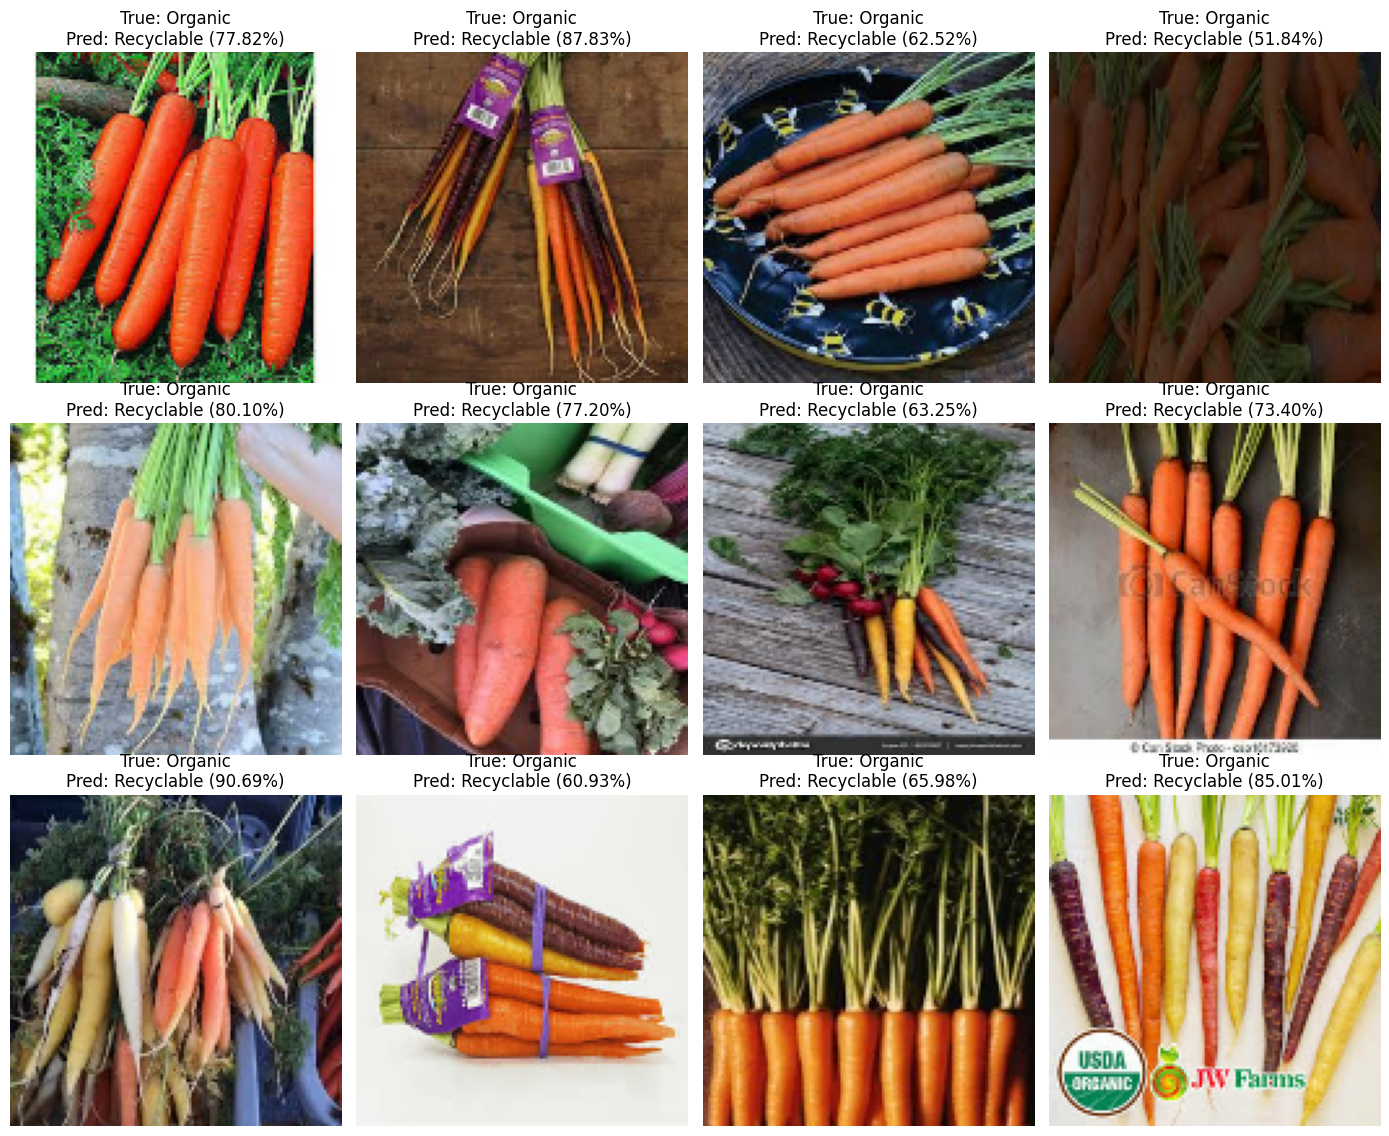

In [ ]:
if misclassified:
    columns = 4
    rows = int(np.ceil(len(misclassified) / columns))
    plt.figure(figsize=(14, 3.8 * rows))

    for index, (image, true_label, pred_label, probability) in enumerate(
        misclassified, start=1
    ):
        ax = plt.subplot(rows, columns, index)
        ax.imshow(image.astype('uint8'))
        confidence = probability if pred_label == 1 else 1.0 - probability
        ax.set_title(
            f'True: {DISPLAY_NAMES[true_label]}\n'
            f'Pred: {DISPLAY_NAMES[pred_label]} ({confidence:.2%})'
        )
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('No misclassified images were found.')

## 14. Predict a user-uploaded image

Run the cell and upload a waste image from your computer.

Saving istockphoto-922676952-612x612.jpg to istockphoto-922676952-612x612.jpg


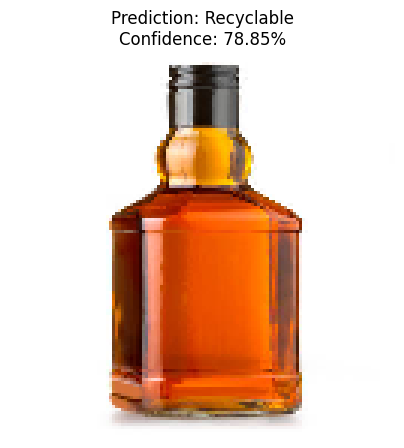

In [ ]:
from google.colab import files

uploaded_files = files.upload()

for filename in uploaded_files:
    image = tf.keras.utils.load_img(filename, target_size=IMG_SIZE)
    image_array = tf.keras.utils.img_to_array(image)
    model_input = tf.expand_dims(image_array, axis=0)

    class_1_probability = float(model.predict(model_input, verbose=0)[0, 0])
    predicted_index = int(class_1_probability >= 0.5)
    predicted_name = DISPLAY_NAMES[predicted_index]
    confidence = (
        class_1_probability if predicted_index == 1
        else 1.0 - class_1_probability
    )

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(f'Prediction: {predicted_name}\nConfidence: {confidence:.2%}')
    plt.axis('off')
    plt.show()

## 15. Save and download the trained model

In [ ]:
FINAL_MODEL_PATH = '/content/waste_cnn_final.keras'
model.save(FINAL_MODEL_PATH)
print('Saved model:', FINAL_MODEL_PATH)

Saved model: /content/waste_cnn_final.keras


In [ ]:
from google.colab import files
files.download(FINAL_MODEL_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Optional experiment: architecture and learning-rate comparison

A fair comparison changes one main factor while keeping the remaining settings fixed.

### Suggested architecture comparison

| Experiment | Base filters | Conv blocks | Dense units | Dropout |
|---|---:|---:|---:|---:|
| Small | 16 | 2 | 64 | 0.25 |
| Baseline | 32 | 3 | 128 | 0.35 |
| Wider | 48 | 3 | 128 | 0.35 |
| Deeper | 32 | 4 | 128 | 0.35 |

### Suggested learning rates

- `1e-4`
- `1e-3`
- `1e-2`

The experiment is disabled by default because it trains several models. Set `RUN_EXPERIMENTS = True` to run it.

In [ ]:
EXPERIMENT_CONFIGS = [
    {
        'name': 'small_lr_1e-3',
        'base_filters': 16,
        'num_blocks': 2,
        'dense_units': 64,
        'dropout_rate': 0.25,
        'learning_rate': 1e-3,
    },
    {
        'name': 'baseline_lr_1e-4',
        'base_filters': 32,
        'num_blocks': 3,
        'dense_units': 128,
        'dropout_rate': 0.35,
        'learning_rate': 1e-4,
    },
    {
        'name': 'baseline_lr_1e-3',
        'base_filters': 32,
        'num_blocks': 3,
        'dense_units': 128,
        'dropout_rate': 0.35,
        'learning_rate': 1e-3,
    },
    {
        'name': 'baseline_lr_1e-2',
        'base_filters': 32,
        'num_blocks': 3,
        'dense_units': 128,
        'dropout_rate': 0.35,
        'learning_rate': 1e-2,
    },
    {
        'name': 'wider_lr_1e-3',
        'base_filters': 48,
        'num_blocks': 3,
        'dense_units': 128,
        'dropout_rate': 0.35,
        'learning_rate': 1e-3,
    },
]

RUN_EXPERIMENTS = False
EXPERIMENT_EPOCHS = 8

In [ ]:
experiment_rows = []
experiment_histories = {}

if RUN_EXPERIMENTS:
    for config in EXPERIMENT_CONFIGS:
        print('\n' + '=' * 80)
        print('Running:', config['name'])

        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED)

        experiment_model = build_cnn(
            base_filters=config['base_filters'],
            num_blocks=config['num_blocks'],
            dense_units=config['dense_units'],
            dropout_rate=config['dropout_rate'],
        )

        experiment_model.compile(
            optimizer=keras.optimizers.Adam(
                learning_rate=config['learning_rate']
            ),
            loss=keras.losses.BinaryCrossentropy(),
            metrics=[
                keras.metrics.BinaryAccuracy(name='accuracy'),
                F1Score(name='f1'),
            ],
        )

        start_time = time.perf_counter()
        experiment_history = experiment_model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EXPERIMENT_EPOCHS,
            class_weight=class_weight,
            verbose=1,
        )
        elapsed_seconds = time.perf_counter() - start_time

        history_df = pd.DataFrame(experiment_history.history)
        experiment_rows.append({
            'name': config['name'],
            'base_filters': config['base_filters'],
            'num_blocks': config['num_blocks'],
            'dense_units': config['dense_units'],
            'dropout_rate': config['dropout_rate'],
            'learning_rate': config['learning_rate'],
            'parameters': experiment_model.count_params(),
            'best_val_f1': history_df['val_f1'].max(),
            'best_val_accuracy': history_df['val_accuracy'].max(),
            'lowest_val_loss': history_df['val_loss'].min(),
            'training_seconds': elapsed_seconds,
        })
        experiment_histories[config['name']] = history_df

    experiment_results = pd.DataFrame(experiment_rows)
    display(experiment_results.sort_values('best_val_f1', ascending=False))
else:
    print('Experiments are disabled. Set RUN_EXPERIMENTS = True and rerun this cell.')

In [ ]:
if RUN_EXPERIMENTS:
    plt.figure(figsize=(10, 6))
    for experiment_name, history_df in experiment_histories.items():
        epochs = np.arange(1, len(history_df) + 1)
        plt.plot(epochs, history_df['val_accuracy'], label=experiment_name)

    plt.xlabel('Epoch')
    plt.ylabel('Validation accuracy')
    plt.title('Architecture and learning-rate comparison')
    plt.legend()
    plt.grid(True)
    plt.show()

# Questions for analysis

1. Are the two classes balanced in the training and test sets?
2. Does the model show underfitting or overfitting? Cite evidence from the learning curves.
3. Which class has lower recall, and what images are frequently misclassified?
4. How does data augmentation affect validation performance?
5. What happens when the learning rate is too low?
6. What happens when the learning rate is too high?
7. Does increasing width or depth always improve validation accuracy?
8. Which configuration gives the best trade-off among accuracy, parameter count, and training time?
9. What changes would be required for deployment in a real waste-sorting system?

# Further extensions

- Increase image resolution to `160 × 160` or `224 × 224`.
- Tune data augmentation strength.
- Add class weights when class imbalance is substantial.
- Compare `Flatten` and `GlobalAveragePooling2D`.
- Compare max pooling and average pooling.
- Tune the classification threshold on validation data.
- Compare the custom CNN with MobileNetV2 or EfficientNet transfer learning.
- Apply Grad-CAM for visual explanation.
- Export the model to TensorFlow Lite for edge deployment.